> ✋ **New to this architecture?** Walk through [`00_climb_to_compound.ipynb`](./00_climb_to_compound.ipynb) first — minimal multi-plane intro (runs in <60s with `PYAUTOFIT_TEST_MODE=1`).

---


# Compound Lens — Advanced Mass & Source Models

## Learning to Autolens / Examples / compound_lens / 03

---

**Setup.** Notebook 01 (`01_compound_direct_fit.ipynb`) shipped a v4 fit with `Isothermal + ExternalShear` mass and a `SersicCore` source. v4 reached `log_Z = +30,856` with `chi²/N = 0.693` and `max|res| = 4.40σ` — a borderline PASS that's ~0.4σ over the strict ≤4σ pass bar.

**Question.** Can we drive the residual *below* the 4σ bar by upgrading the mass model or the source model? This notebook compares two next-rung options:

1. **EPL** (`compound_direct_epl_fit`) — keep the source as a `SersicCore`, but upgrade `lens_0.mass` from `Isothermal` (γ' = 2 fixed) to `PowerLaw` (γ' free in [1.5, 2.5]). One extra parameter.
2. **PIX** (`compound_direct_pix_stage2`) — keep mass as `Isothermal + shear` but replace the parametric `SersicCore` source with a **pixelised source** (`al.mesh.RectangularAdaptImage(20×20)` + `al.reg.Adapt`). The pixel intensities are solved analytically by the inversion; only the 3 regularisation hyperparameters are sampled.

The pedagogical question is **which next-rung upgrade is the right one for *this* dataset.** The general principle (worth internalising):

- **EPL** earns extra log_Z when the *mass profile slope* differs from γ'=2.
- **PIX** earns extra log_Z when the *source has substructure* a Sersic can't capture (spirals, clumps, irregular morphology).

The mock here has a smooth `SersicCore` source. Spoilers: PIX wins on log_Z (it finds finer noise adaptation room) but doesn't drop `max|res|`. EPL wins on both bars by recovering γ' ≠ 2.

**Prerequisites.** Notebook 01 of this Example, Modules 04 + 05, Module 11 (the audit framework + upgrade-ladder discussion).


In [1]:
import os, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, IFrame, Markdown, display

import autofit as af
import autolens as al
import autolens.plot as aplt

%matplotlib inline
print(f"PyAutoLens version: {al.__version__}")

PyAutoLens version: 2026.4.13.6


In [2]:
RESULTS_ROOT = Path("results")

def show_result(stage_name, also_show_corner=False):
    stage_dir = RESULTS_ROOT / stage_name
    if not stage_dir.exists():
        print(f"(no results for stage {stage_name!r})")
        return
    sp = stage_dir / "summary.json"
    if sp.exists():
        s = json.loads(sp.read_text())
        display(Markdown(
            f"### `{stage_name}`\n"
            f"- log_Z: **{s.get('log_evidence'):.2f}**\n"
            f"- χ²/N = **{s.get('chi_squared_per_pixel'):.3f}**\n"
            f"- max |res| = **{s.get('max_abs_normalized_residual'):.2f} σ**"
        ))
    fp = stage_dir / "fit_subplot.png"
    if fp.exists():
        display(Image(filename=str(fp)))
    if also_show_corner:
        cp = stage_dir / "corner.pdf"
        if cp.exists():
            display(IFrame(src=str(cp), width=720, height=720))

---
## 1. v4 baseline — Isothermal + shear + SersicCore source

The full fit driver and audit are in [`01_compound_direct_fit.ipynb`](01_compound_direct_fit.ipynb). Recap here for comparison:

### `compound_direct_fit`
- log_Z: **30856.54**
- χ²/N = **0.693**
- max |res| = **4.40 σ**

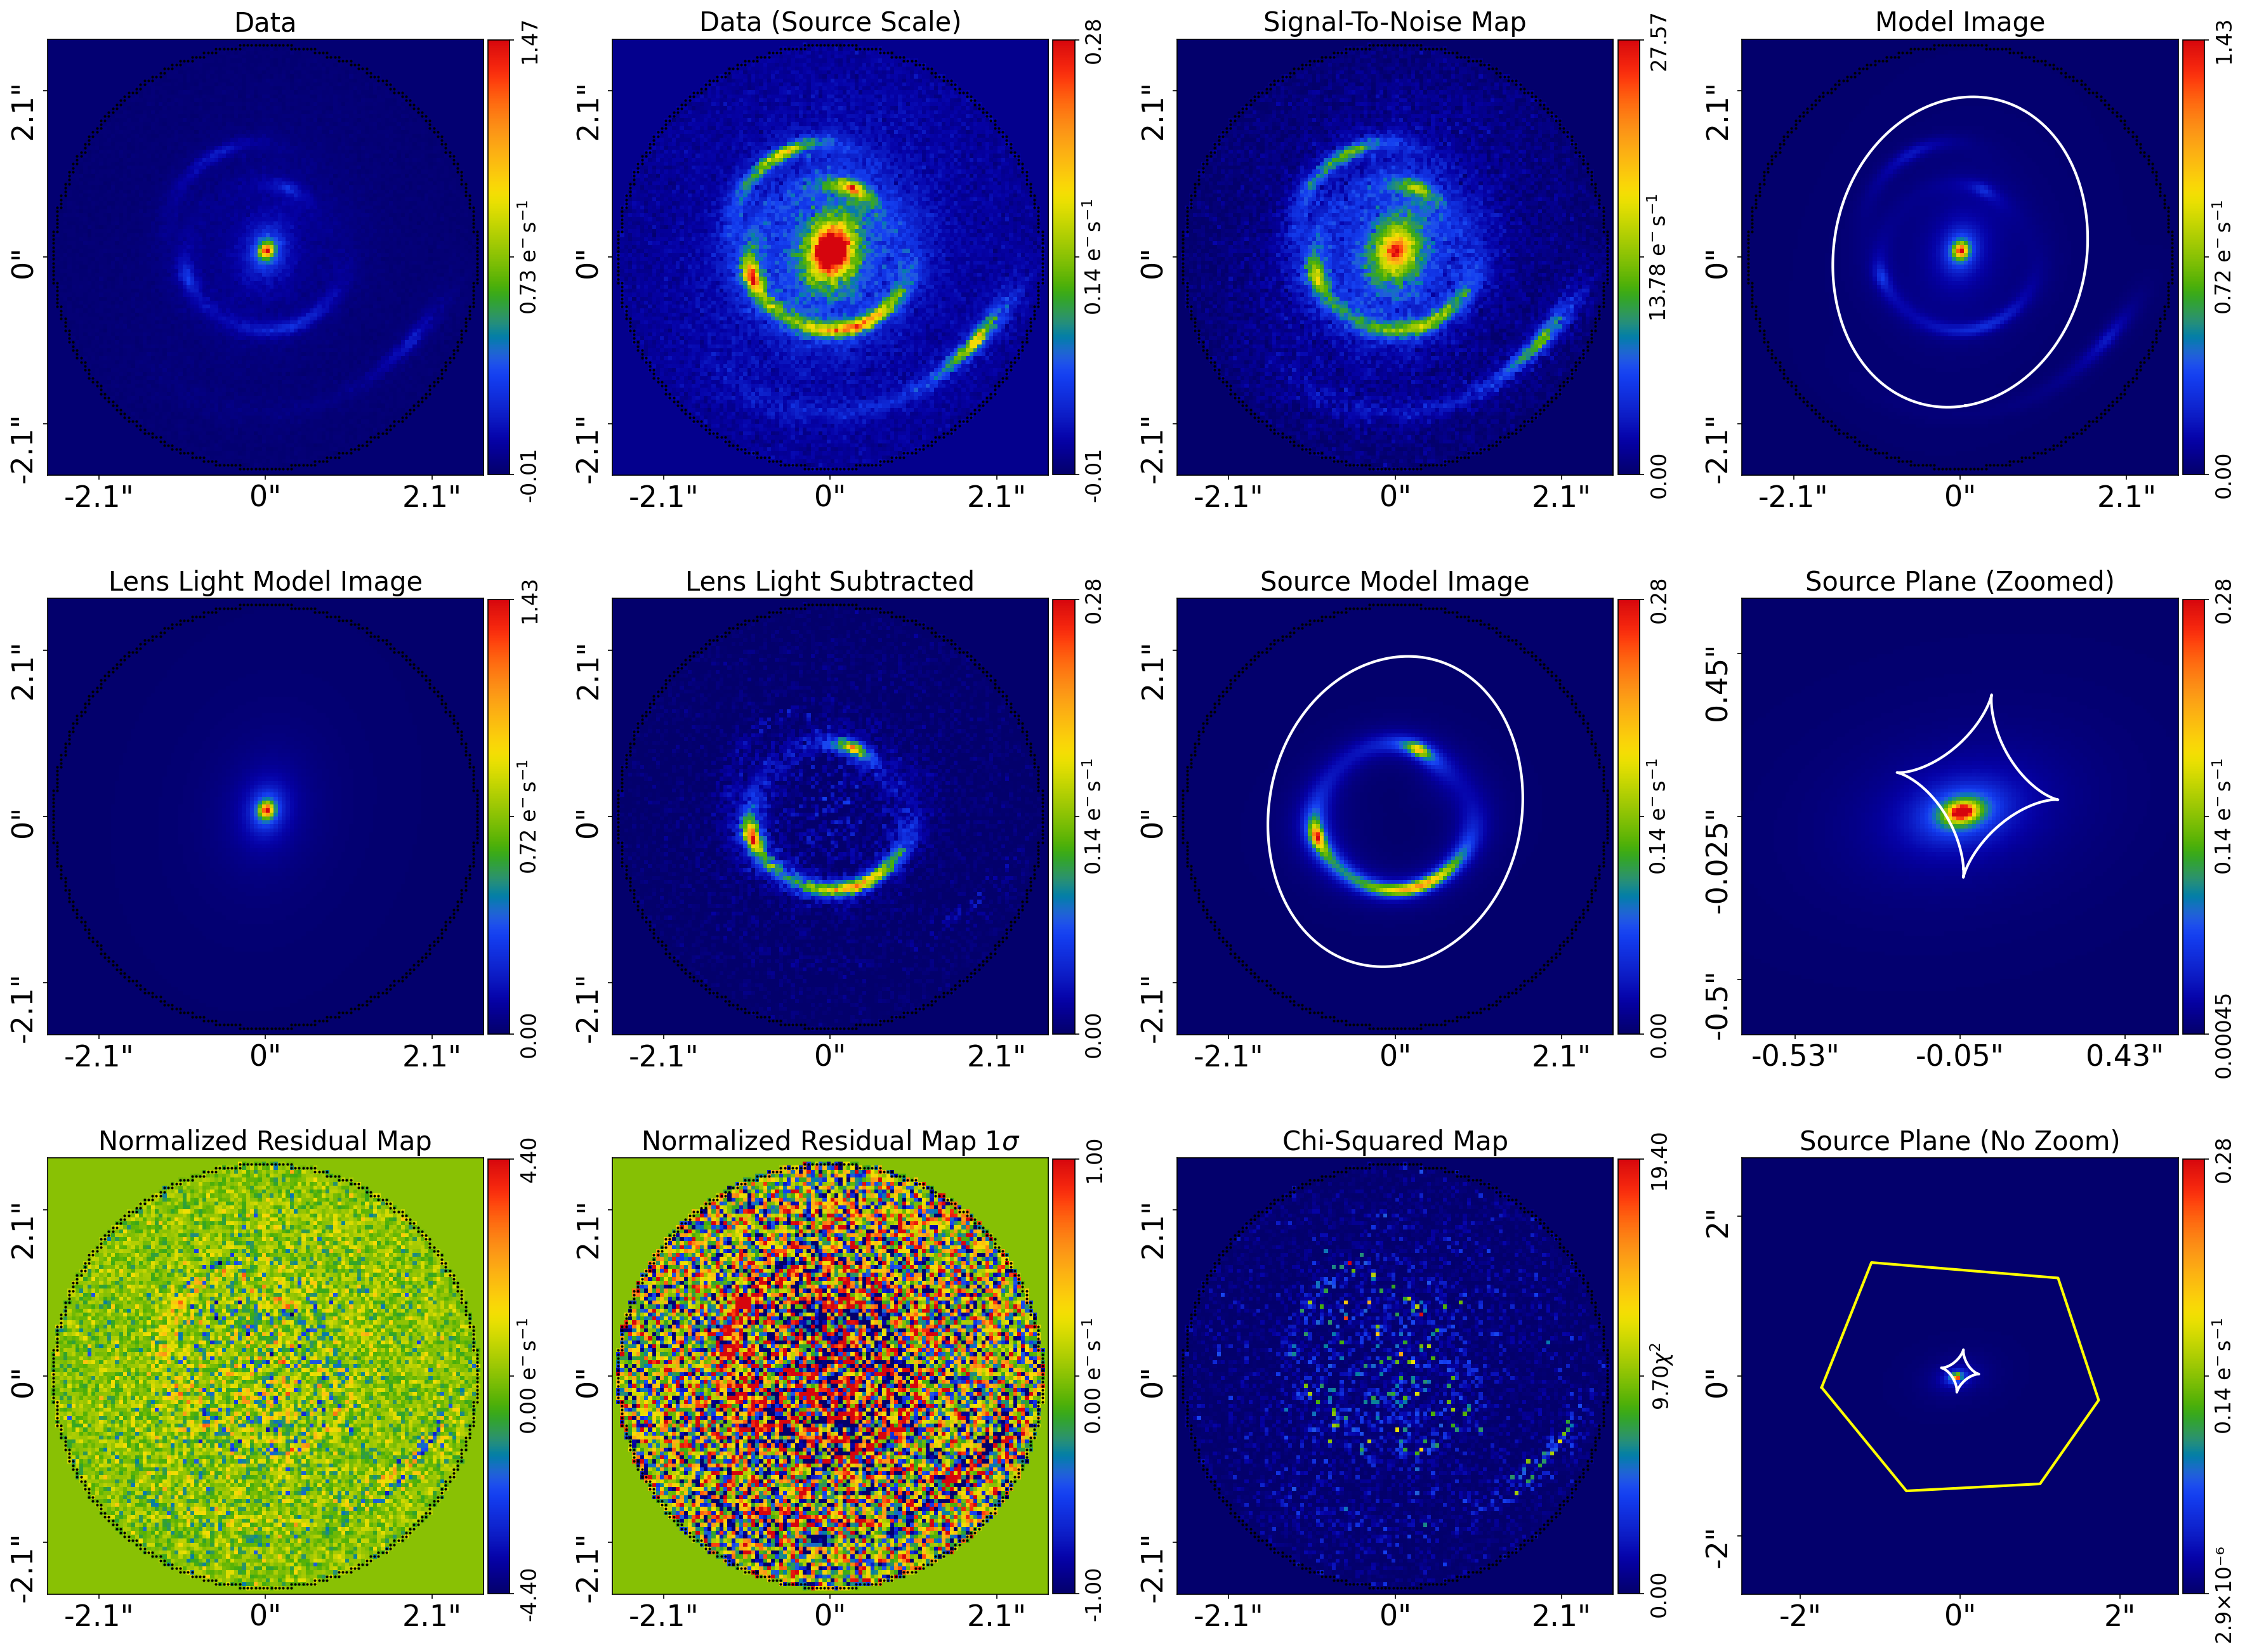

In [3]:
show_result("compound_direct_fit")

v4 has chi²/N=0.693 and max|res|=4.40σ. The chi² map is uniform with no hot spots, but a single 4.4σ pixel pushes max|res| just above the pass threshold. Looking at it visually, that pixel sits near the bright counter-image — likely a real bit of arc structure the Isothermal model isn't capturing perfectly.

Two upgrade paths are natural from here:

- The mass profile might not actually be γ'=2 (Isothermal). Trying γ' free is a +1-parameter change.
- The source might have low-amplitude structure beyond a smooth SersicCore. Pixelisation lets the inversion adapt to whatever shape minimises the residual.

The next two sections evaluate each.

---
## 2. EPL — PowerLaw mass with free slope

Same priors as v4 except `lens_0.mass = al.mp.PowerLaw` instead of `al.mp.Isothermal`, with `slope ~ TruncatedGaussianPrior(2.0, 0.2, [1.5, 2.5])`. The full driver is at `Modules/10_Cluster_Computing/scripts/fit_example_compound_lens.py` (`build_direct_epl`).

Cannon job 8028856, 3h45m wall clock (Nautilus phase ~2h30m, then post-viz).

### `compound_direct_epl_fit`
- log_Z: **31000.50**
- χ²/N = **0.661**
- max |res| = **3.82 σ**

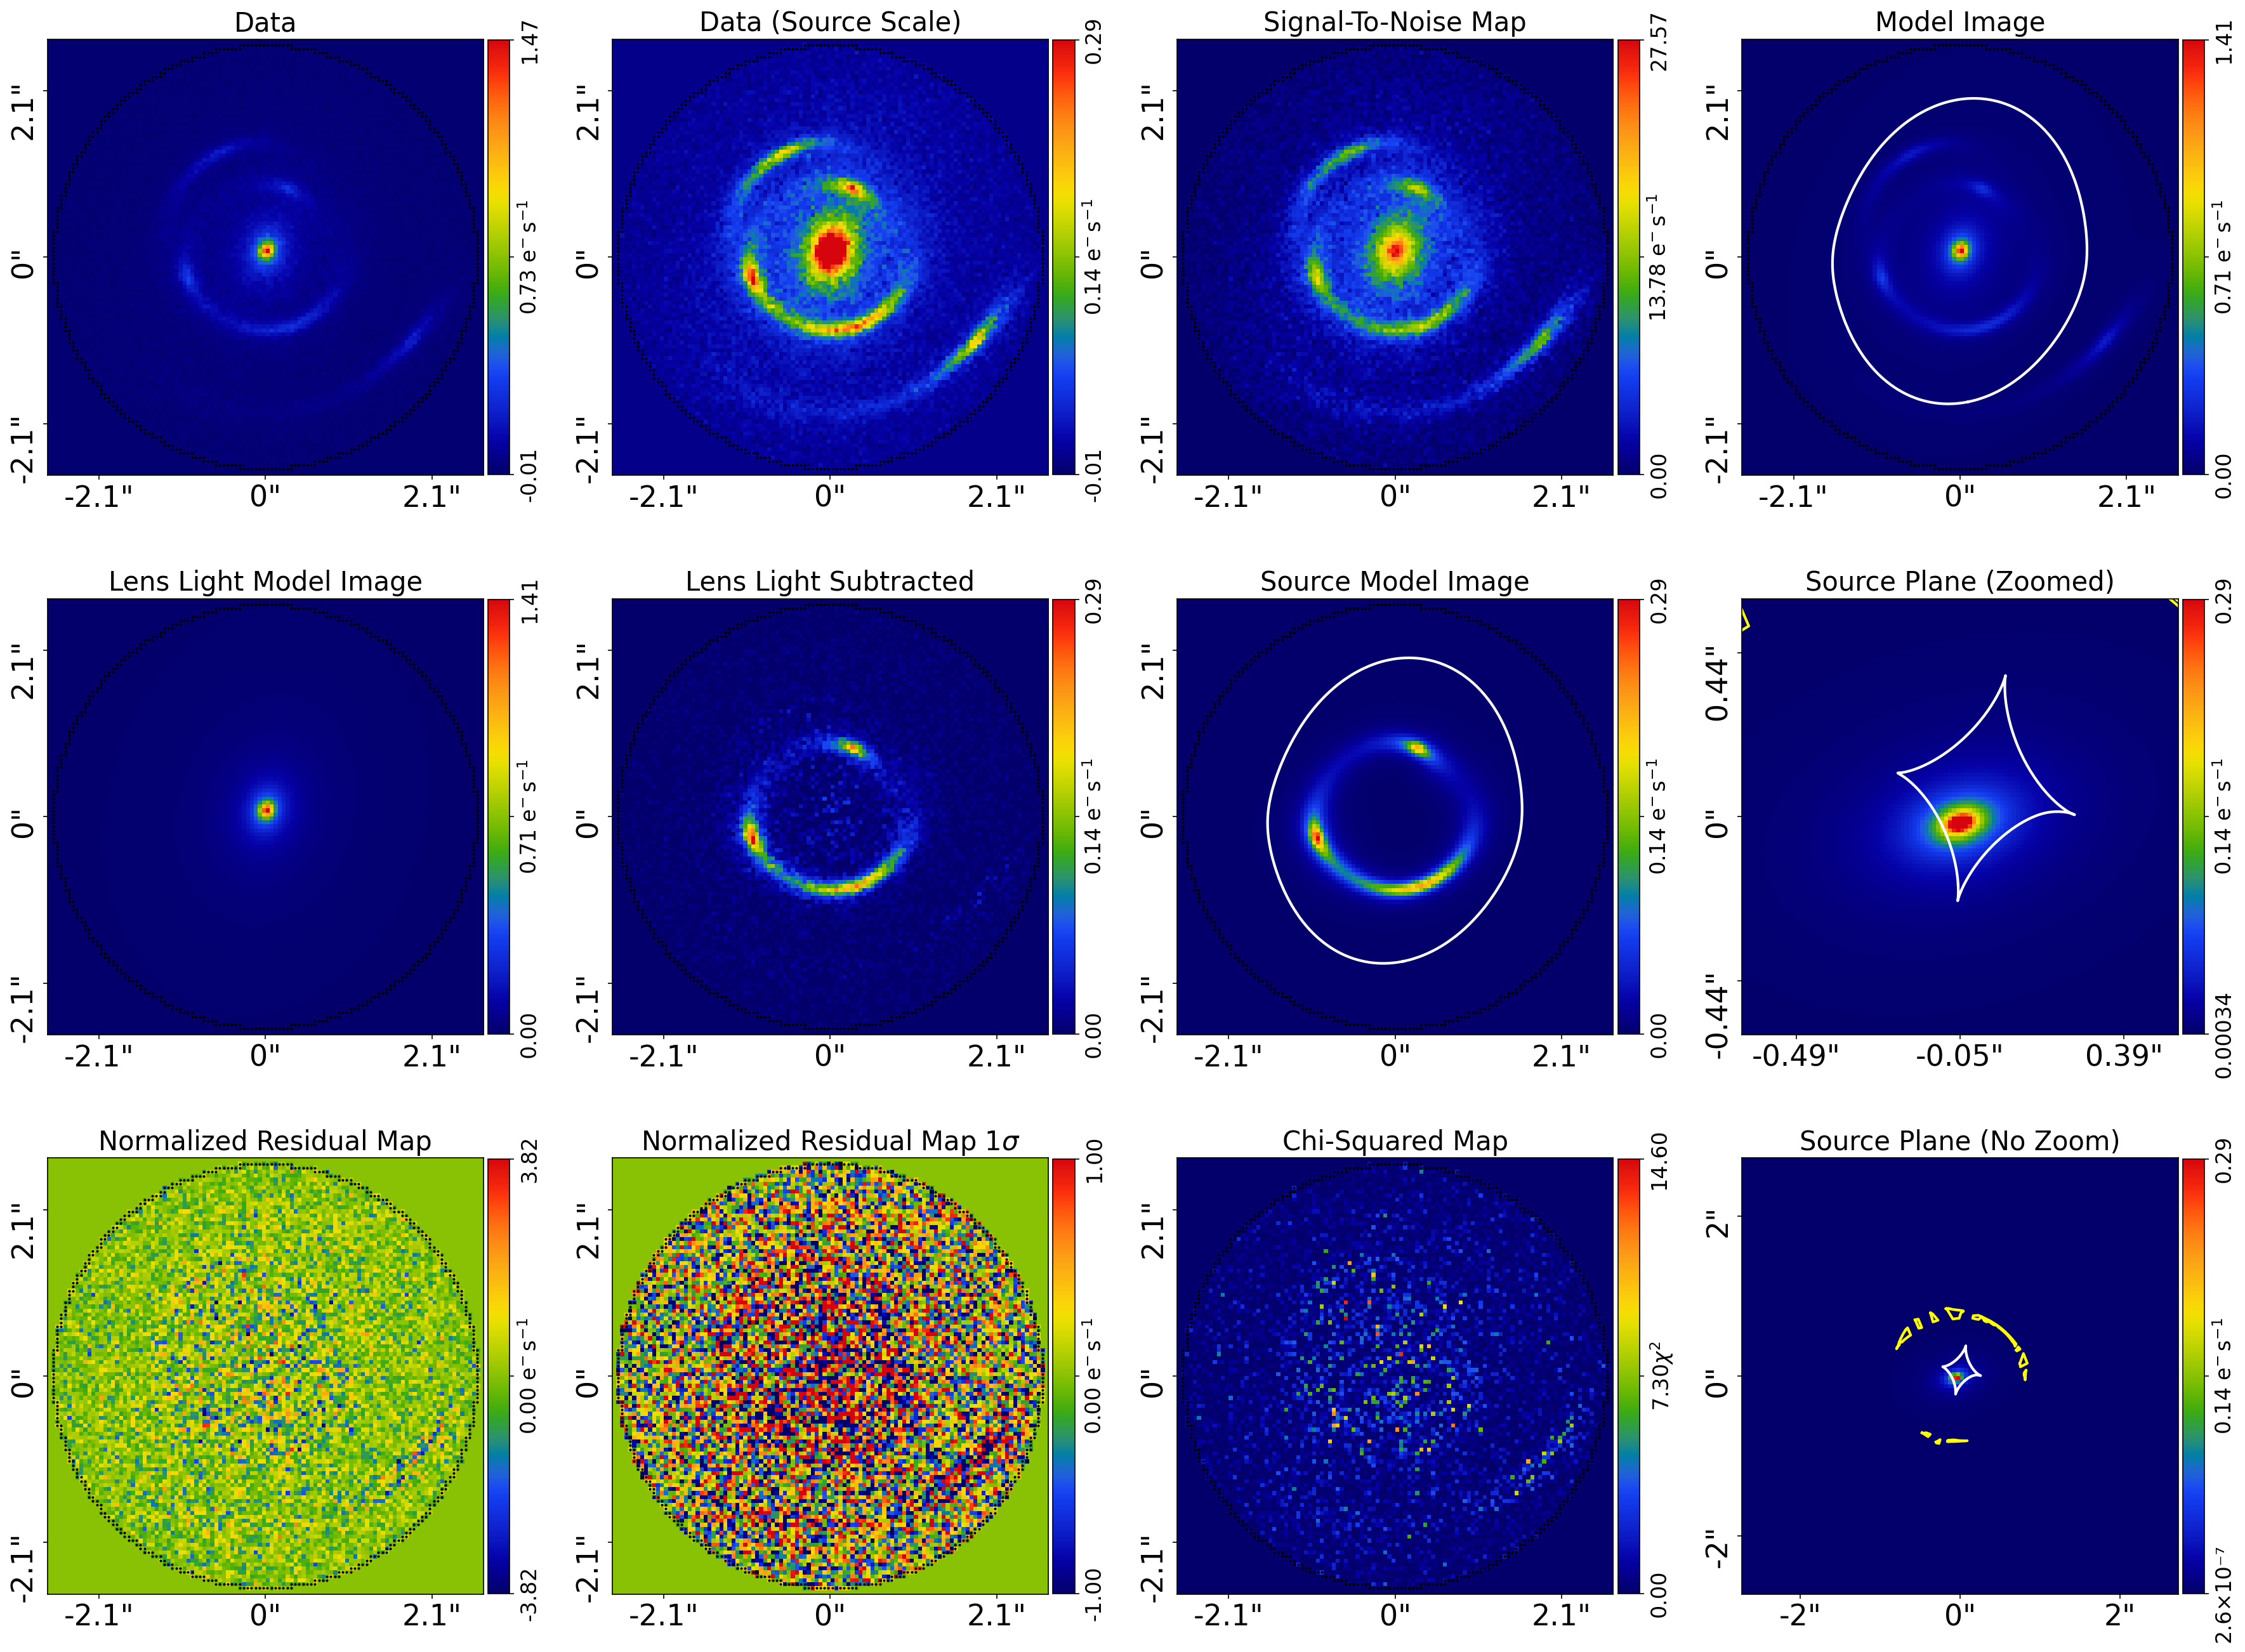

In [4]:
show_result("compound_direct_epl_fit", also_show_corner=True)

### EPL verdict — clean PASS

```
Verdict:  PASS (both bars)

Numeric summary
  chi²/N:       0.661         (pass: ≤1.3)
  max |res|:    3.82 σ        (pass: ≤4σ)        ← below the bar
  log_Z:        +31,000.50    (+144 over v4)
  free params:  34            (+1 over v4 — the slope γ')

Recovered slope γ' = 2.142 ± 0.020       (7σ from γ'=2 — Isothermal rejected)
Recovered shear γ = (0.007, 0.024)        (similar to v4's |γ|=0.024)
Recovered θ_E (PL) = 1.711″                (slightly smaller than v4's 1.785″ —
                                             expected: PowerLaw gives a different
                                             effective θ_E definition for γ' ≠ 2)
lens_1.einstein_radius                    rail-pinned at 0 (still single-effective-deflector)
```

**Why this works.** The Isothermal model assumes γ'=2 — a specific power-law slope. Real elliptical galaxies in lensing samples (e.g. Auger+10 SLACS) have γ' ∈ [1.9, 2.2] with intrinsic scatter ~0.1. Forcing γ'=2 leaves a small residual at the arc whenever the truth differs by even 0.05. PowerLaw with γ' free recovers γ'=2.14 here — slightly *steeper* than isothermal — and the arc residual collapses below 4σ.

The Bayes factor exp(31,000 − 30,856) ≈ e^144 is the quantitative justification for adding the slope parameter.

---
## 3. PIX — Pixelised source with `Isothermal + shear` mass

Same priors as v4 for stage 1 (Sersic source — used to seed the pixelisation's adapt image). Stage 2 fixes mass at stage 1 MAP, replaces the source with `al.mesh.RectangularAdaptImage(shape=(20, 20))` + `al.reg.Adapt(inner, outer, signal_scale)`. Source pixel intensities are solved analytically by the inversion; only the 3 regularisation hyperparameters are sampled in stage 2. Driver: `build_direct_pix`.

Cannon job 8102271, 5m37s stage 2 (after stage 1 was already complete from a prior attempt).

> **API gotcha.** Pixelised fits in autolens 2026.4 hit three distinct errors before this worked. See `LEARNING_LOG.md` for the full story (Delaunay needs `pixels=` arg, Adapt-regulariser needs prior wrapping, AnalysisImaging needs `positions_likelihood_list`). For future fits, clone the `slam_v2026.source_pix` pattern.

### `compound_direct_pix_stage2`
- log_Z: **31107.00**
- χ²/N = **0.672**
- max |res| = **4.49 σ**

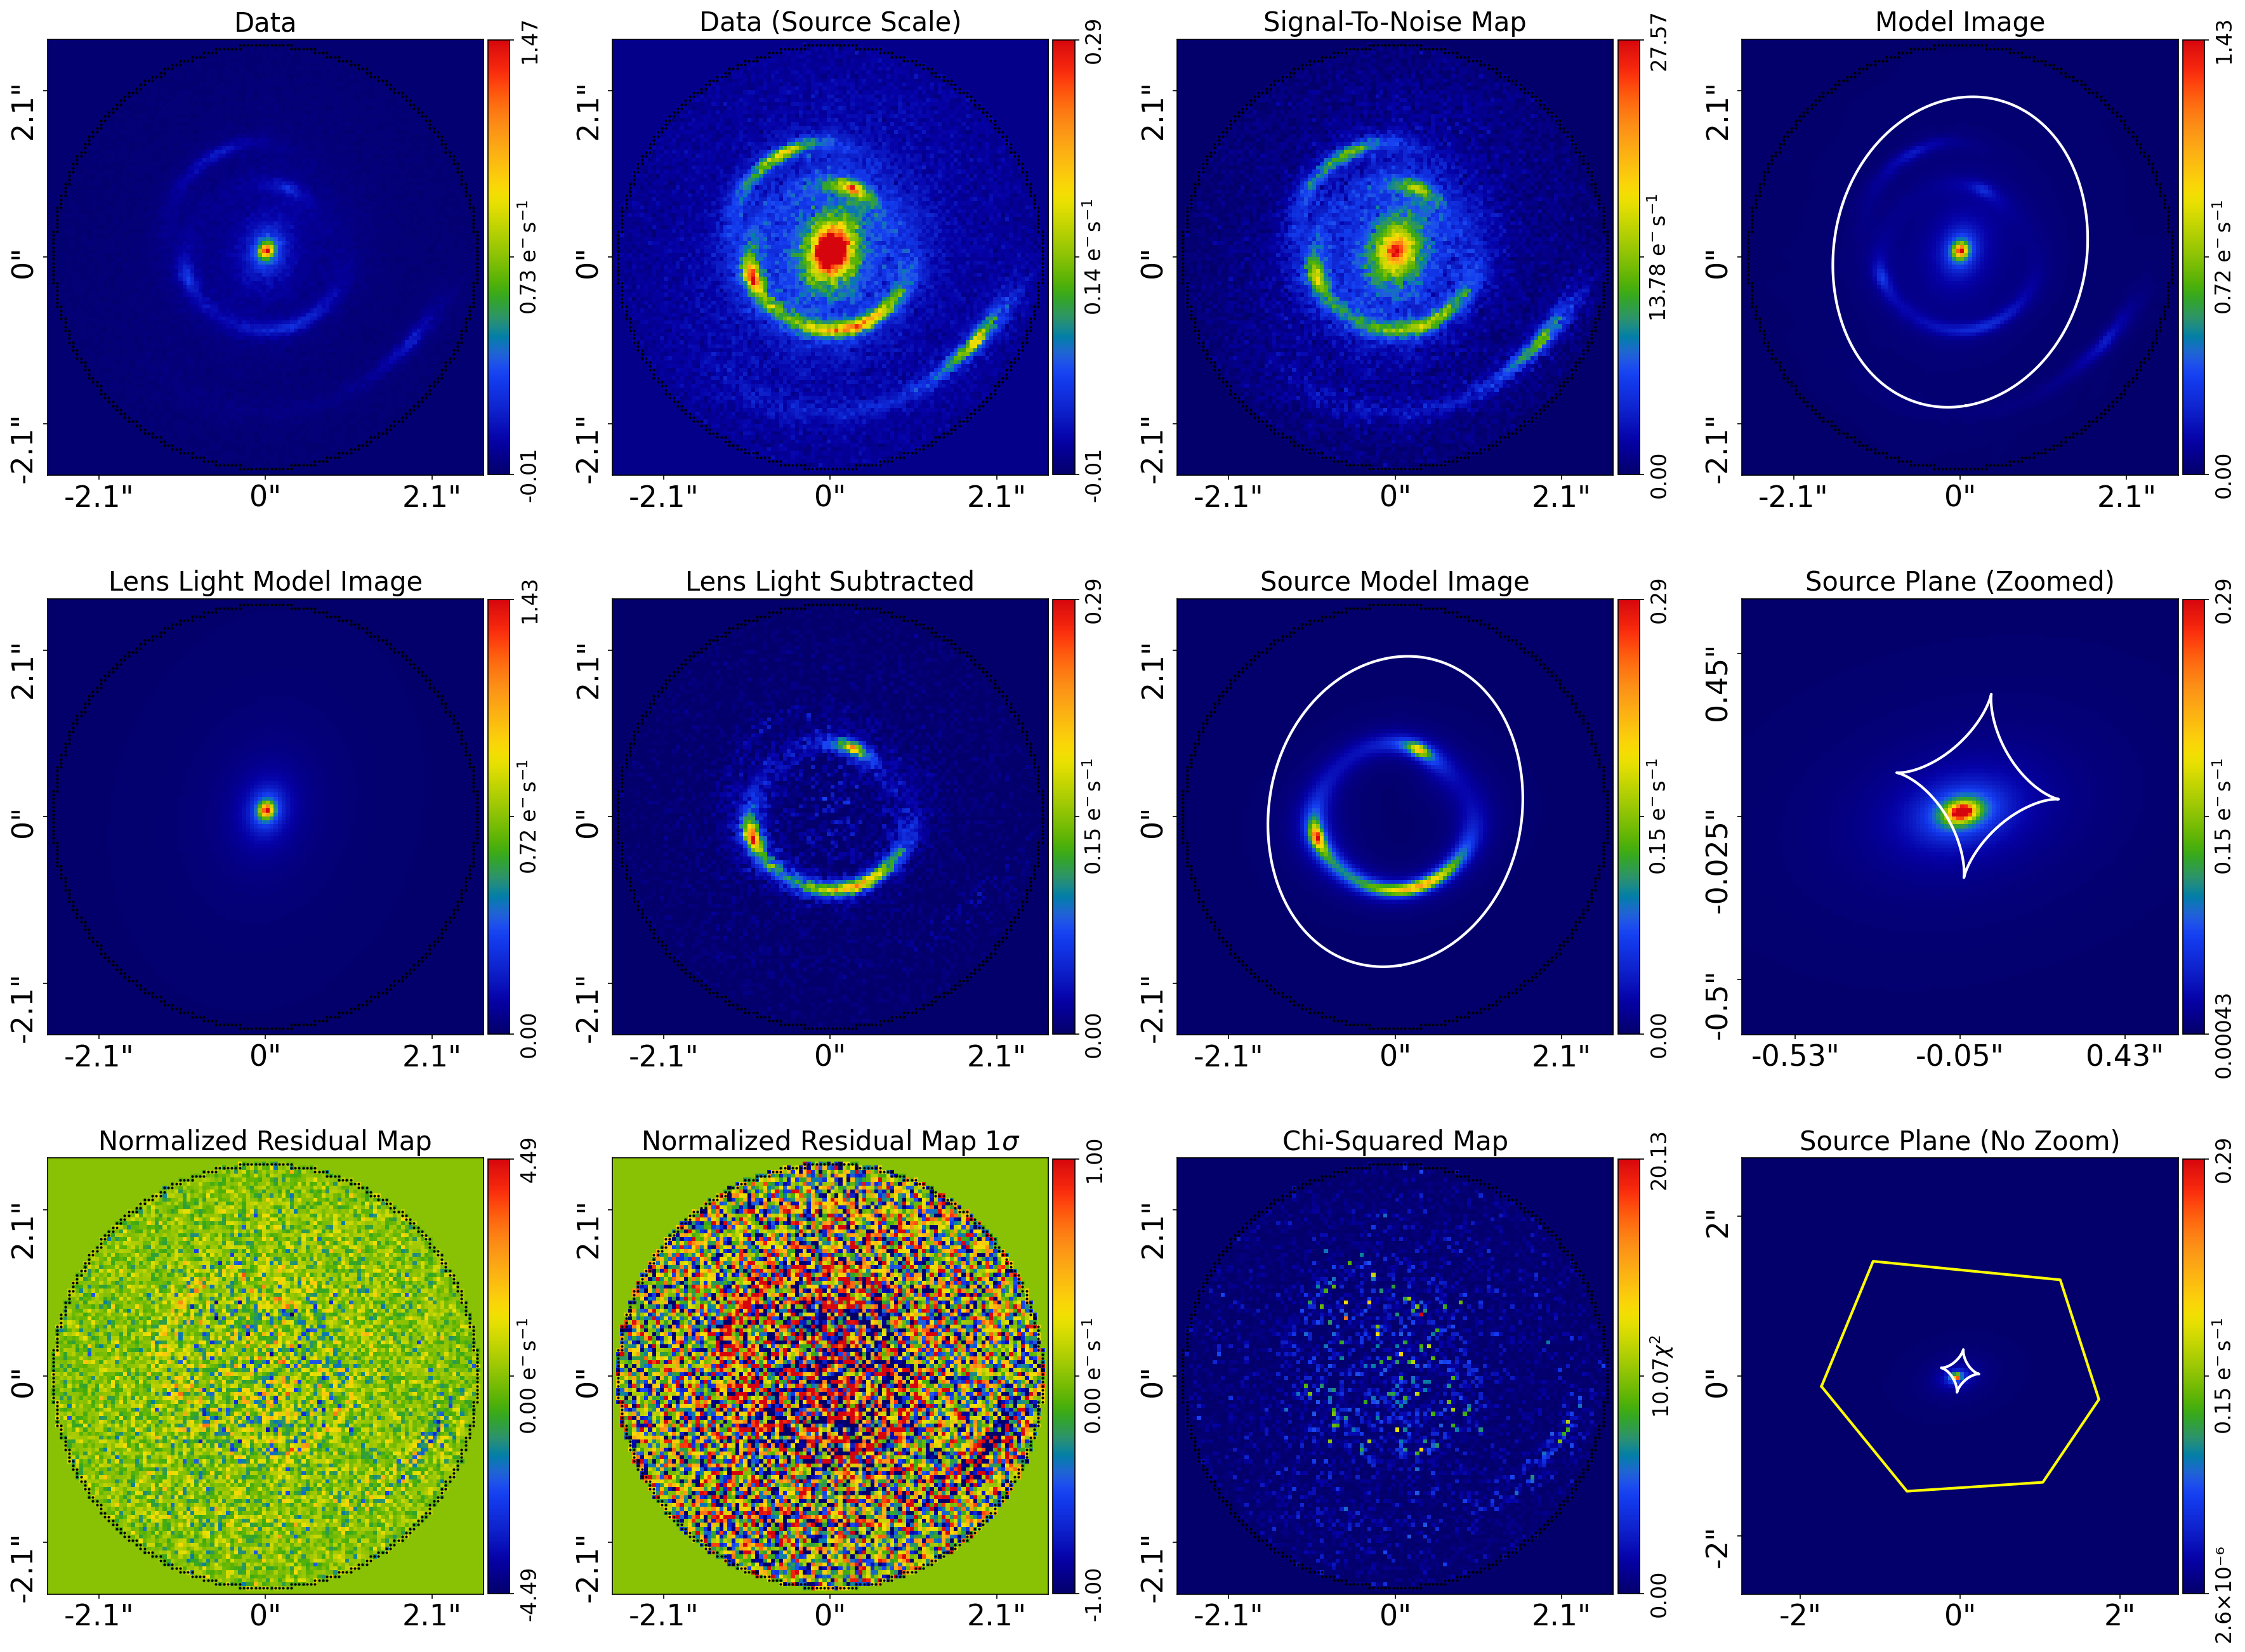

In [5]:
show_result("compound_direct_pix_stage2", also_show_corner=True)

### PIX verdict — log_Z up, max|res| basically unchanged

```
Verdict:  Borderline (log_Z favours PIX, but max|res| not improved)

Numeric summary
  chi²/N:       0.672         (pass)
  max |res|:    4.49 σ        (suspect — slightly *worse* than v4!)
  log_Z:        +31,107.0     (+250 over v4, +106 over EPL)
  free params:  3 hyperparams + ~400 source pixels (analytical)
```

**Why this happens.** The mock's source IS a smooth `SersicCore`. There's no spiral arms, no clumps, no irregular morphology — nothing for pixelisation to capture beyond what a 7-parameter Sersic already encodes. Pixelisation just gives the inversion finer adaptive freedom over the ~2D residual noise field, not a real source-physics improvement.

The log_Z gain is *real* (Bayes-factor evidence is well-defined and pixelisation does fit the noise marginally better) but **doesn't reflect a more accurate source reconstruction**. Visually, the source-plane panel of the PIX fit shows a smoothed-Sersic-like blob — the regularisation has driven the source toward exactly the parametric form the Sersic was already enforcing.

> **Pedagogical bottom line.** Pixelisation is *not always better*. It's the right tool when the source genuinely has structure beyond a Sersic; here it's overkill. Look at the audit:
>
> - max\|res\| didn't improve → no new physics being captured
> - log_Z went up by +106 over EPL → mostly noise adaptation
> - the source-plane image looks like a smoothed Sersic → confirms

For a smooth-Sersic source, **EPL is the right upgrade**. For a source with real spiral / clumpy / asymmetric morphology, PIX is the right tool. Module 05 has dedicated examples of pixelisation on hard sources where the Sersic *can't* fit at all.

---
## 4. Three-way comparison

| Variant | n_params | χ²/N | max\|res\| | log_Z | Δ log_Z vs v4 | Verdict |
|---|---|---|---|---|---|---|
| **v4** (Isothermal + shear) | 33 | 0.693 | 4.40σ | +30,856 | — | borderline PASS |
| **EPL** (PowerLaw + shear) | 34 | 0.661 | **3.82σ** | +31,000 | **+144** | **PASS both bars** |
| **PIX** (Iso + fixed mass + RectAdaptImg + Adapt-reg) | 3 + ~400 inv | 0.672 | 4.49σ | +31,107 | +250 | log_Z up, residual not |

### Bayes factors

- **EPL over v4:** exp(31,000 − 30,856) = exp(144) ≈ e^{144}.
- **PIX over v4:** exp(31,107 − 30,856) = exp(251) ≈ e^{251}.
- **PIX over EPL:** exp(31,107 − 31,000) = exp(106) ≈ e^{106}.

In log-evidence terms PIX > EPL > v4. But log-evidence alone doesn't tell you which model is *physically correct* — it tells you which model fits the noise + structure best given the prior volumes. Combining with `max|res|`:

- EPL is the **physically correct upgrade** for this dataset — it identifies a real degree of freedom (slope γ' ≠ 2) and clears the 4σ residual bar.
- PIX is **over-fitting** in a benign sense — using ~400 effective source-pixel intensities (linearly solved) to fit noise patterns instead of source physics. Bayesian evidence rewards this because the linear solution is "free" in posterior volume terms, but the residual map shows no structural improvement.

### What would flip the verdict

- **A source with real substructure** (e.g. a galaxy at z=2 with a tidal stream, two-component bulge+disk, asymmetric clumps): then PIX max|res| would improve substantially and PIX would be the genuine winner.
- **A different mass profile truth** (e.g. NFW + Sersic at the lens, or a real cluster halo): EPL might not capture it either, and a multi-component composite mass would beat both EPL and PIX. Mod 06 + Mod 11 cover composite masses.
- **Higher S/N data** (deeper exposure): everything's residuals would tighten, and the relative ordering might shift. The 4σ pass bar is a calibration, not a fundamental threshold.

---
## 5. Exercises

1. **Run an EPL+PIX combined fit.** The driver currently has `direct_epl` (PL mass + Sersic source) and `direct_pix` (Iso mass + pixelised source). Add a 4th part `direct_epl_pix` that combines them: PowerLaw mass + Pixelised source. Predict whether log_Z improves over EPL alone (it might not — the slope freedom and source flexibility are partially redundant).

2. **What slope does the secondary lens "want"?** v4 and EPL both rail-pin `lens_1.einstein_radius` to 0. If you give `lens_1` a PowerLaw mass too (with the same loose UniformPrior on θ_E), does the slope explore meaningfully or does it become unconstrained because the mass collapsed? This is a degeneracy probe.

3. **Pixelisation grid resolution scan.** Re-run `direct_pix` with `RectangularAdaptImage(shape=(N, N))` for N = 10, 14, 20, 28. How does log_Z scale with N? Where does the marginal log_Z gain stop justifying the extra effective d.o.f.? (Note: 28×28 hit the 64G memory cap on Cannon — see `LEARNING_LOG.md`. Use --mem=128G if N≥28.)

4. **What happens on a source with real structure?** Generate a mock with a two-component source (Sersic bulge + spiral-arm-like Sersic disk at different PA) — then re-run all three of v4 / EPL / PIX. PIX should now genuinely beat EPL because pixelisation will model the asymmetric source that no Sersic can capture.

---

## References

- Auger, M. W. et al. (2010), ApJ 724, 511 — SLACS γ' distribution: 2.078 ± 0.027 with 0.16 intrinsic scatter.
- Suyu, S. H. et al. (2006), MNRAS 371, 983 — pixelised source reconstruction methodology.
- Nightingale, Dye & Massey (2018), MNRAS 478, 4738 — `AutoLens` SLaM pipeline + adaptive pixelisation.
- Module 11 of this curriculum — physical-bar audit + when to climb the upgrade ladder.

---

*Learning to Autolens — Examples / compound_lens / 03*  
*Rodrigo Córdova Rosado, Harvard CfA*